# Part 5 – Guardrail Pipeline

## 1. Imports

In [12]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Fix seeds
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

seed = 42
set_seed(seed)

train_path = "jigsaw-unintended-bias-train.csv"
columns_ = ['comment_text', 'toxic']
toxicity_threshold = 0.5

## 2. Load eval set & sample 1,000 comments

In [13]:
print("Loading Validation Data for Evaluation...")
df = pd.read_csv(train_path, usecols=columns_).dropna(subset=['toxic']).drop_duplicates(subset=['comment_text'])
df['toxic_binarized'] = (df['toxic'] >= toxicity_threshold).astype(int)

_, val_df = train_test_split(df, test_size=20000, train_size=100000, random_state=seed, stratify=df["toxic_binarized"])
val_df = val_df.reset_index(drop=True)

# Sample 1,000 random comments for Part 5 Evaluation
eval_df = val_df.sample(n=1000, random_state=seed).copy()
print(f"Sampled {len(eval_df)} comments for multi-layer evaluation.")

Loading Validation Data for Evaluation...
Sampled 1000 comments for multi-layer evaluation.


## 3. Input Filter Analysis

In [14]:
from pipeline import input_filter, BLOCKLIST
import pandas as pd

print("### Layer 1 Analysis (Pre-Filter on 1,000 comments) ###")

filter_results = []
for _, row in eval_df.iterrows():
    text = str(row['comment_text'])
    decision = input_filter(text)
    if decision:
        filter_results.append({
            "category": decision["category"],
            "confidence": decision["confidence"]
        })

filter_df = pd.DataFrame(filter_results)
if not filter_df.empty:
    blocked_counts = filter_df['category'].value_counts()
    print(f"Total comments blocked by Regex pre-filter: {len(filter_df)} / 1000")
    print("\nBlock distribution by category:")
    print(blocked_counts.to_string())
    
    # Plotting
    plt.figure(figsize=(8, 4))
    blocked_counts.plot(kind='bar', color='salmon')
    plt.title('Blocked Comments by Regex Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No comments were blocked by the Regex pre-filter.")

### Layer 1 Analysis (Pre-Filter on 1,000 comments) ###
No comments were blocked by the Regex pre-filter.


## 4. Initialise the full pipeline

In [ ]:
from pipeline import ModerationPipeline

# Ensure this subset has no overlap with eval_df by using remaining validation data.
remaining_val_df = val_df.drop(eval_df.index)
calib_subset = remaining_val_df.sample(n=2000, random_state=42)

calib_texts = calib_subset['comment_text'].fillna("").astype(str).tolist()
calib_labels = calib_subset['toxic_binarized'].values

print("Initializing the production pipeline...")
pipeline = ModerationPipeline(model_path="./mitigated_model")

print(f"Fitting Isotonic Calibrator on {len(calib_texts)} validation samples...")
# This executes a forward pass on the text samples internally inside pipeline.py
pipeline.fit_calibrator(calib_texts, calib_labels)
print("Calibration complete.")

Initializing the production pipeline...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 254.40it/s]


Fitting Isotonic Calibrator on 2000 validation samples...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 10932.52it/s]


Calibration complete.


## 5. Run pipeline on 1,000 comments

In [17]:
print("Running the pipeline on 1,000 evaluation examples...")

results = []
for idx, row in eval_df.iterrows():
    text = str(row['comment_text']).strip()
    
    # Pipeline returns dict: {"decision": ..., "layer": ..., "confidence": ...}
    decision = pipeline.predict(text)
    
    results.append({
        "comment_text": text,
        "true_label": row['toxic_binarized'],
        "decision": decision["decision"],
        "layer": decision["layer"],
        "confidence": decision.get("confidence"),
        "category": decision.get("category", "N/A")
    })

results_df = pd.DataFrame(results)
print("Pipeline complete.")

results_df.head(10)

Running the pipeline on 1,000 evaluation examples...
Pipeline complete.


,comment_text,true_label,decision,layer,confidence,category
0,China has been sending PhD students to study i...,0,allow,model,0.072593,N/A
1,Glad I am not the only one that seen this.\n\n...,0,allow,model,0.082729,N/A
2,"""Any actual truth is not important""..couldn't ...",0,allow,model,0.082729,N/A
3,I hope you are joking. Imagine all those 'A' ...,0,allow,model,0.082729,N/A
4,"For what it's worth, we got round trips on Uni...",0,allow,model,0.084014,N/A
5,"Apparently it is ""uncivil"" to disagree with an...",0,allow,model,0.084014,N/A
6,So is Domento saying we ban all purchases of p...,0,allow,model,0.064610,N/A
7,It's clear you don't understand that public sc...,0,allow,model,0.084014,N/A
8,The sad part is that you or I would go to jail...,0,allow,model,0.072593,N/A
9,Your fear does not trump other's individual fr...,0,allow,model,0.072593,N/A


## 6. Layer distribution

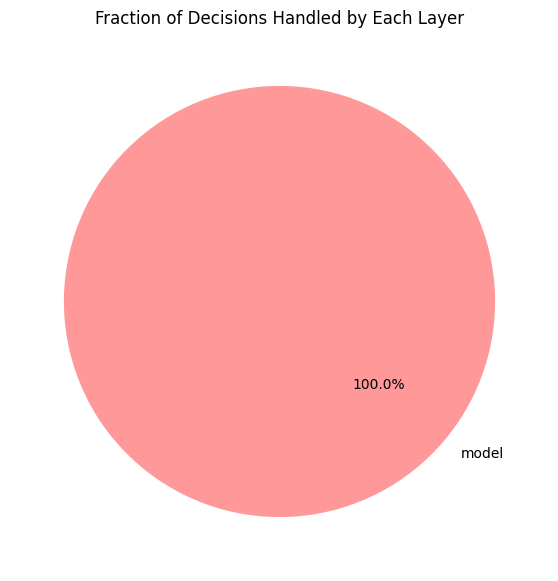

Decisions breakdown:
decision
allow    1000
Name: count, dtype: int64

### Auto-actioned Subset (Layer 2 confident + Filter Blocks) Metrics ###
F1 (Macro): 0.4786
Precision:  0.4590
Recall:     0.5000
Subset Size: 1000 / 1000

### Review-queue Subset Analytics ###
No items sent to the review queue.


In [ ]:
layer_counts = results_df['layer'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(layer_counts, labels=layer_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Fraction of Decisions Handled by Each Layer')
plt.show()

decision_counts = results_df['decision'].value_counts()
print("Decisions breakdown:")
print(decision_counts)

# Requirement: For the auto-actioned subset (Layer 2 confident decisions only, excluding the review queue): 
# what is the model’s F1, precision, and recall?

auto_actioned_df = results_df[results_df['decision'].isin(["block", "allow"])].copy()

# "block" maps to 1, "allow" maps to 0
auto_preds = auto_actioned_df['decision'].apply(lambda x: 1 if x == "block" else 0).values
auto_true = auto_actioned_df['true_label'].values

print("\n### Auto-actioned Subset (Layer 2 confident + Filter Blocks) Metrics ###")
if len(auto_preds) > 0:
    auto_f1 = f1_score(auto_true, auto_preds, average='macro')
    auto_prec = precision_score(auto_true, auto_preds, average='macro')
    auto_rec = recall_score(auto_true, auto_preds, average='macro')
    print(f"F1 (Macro): {auto_f1:.4f}")
    print(f"Precision:  {auto_prec:.4f}")
    print(f"Recall:     {auto_rec:.4f}")
    print(f"Subset Size: {len(auto_preds)} / 1000")
else:
    print("No confident decisions generated.")

# Requirement: For the review-queue subset: what is the actual toxic/non-toxic breakdown (using ground-truth labels)?

review_df = results_df[results_df['decision'] == "review"].copy()
print("\n### Review-queue Subset Analytics ###")
if not review_df.empty:
    actual_toxic = len(review_df[review_df['true_label'] == 1])
    actual_nontoxic = len(review_df[review_df['true_label'] == 0])
    print(f"Total Sent to Review: {len(review_df)} / 1000")
    print(f" - Actual Toxic (Ground Truth=1): {actual_toxic} ({actual_toxic/len(review_df)*100:.1f}%)")
    print(f" - Actual Non-Toxic (Ground Truth=0): {actual_nontoxic} ({actual_nontoxic/len(review_df)*100:.1f}%)")
else:
    print("No items sent to the review queue.")

## 7. Threshold sensitivity analysis

In [23]:
def evaluate_thresholds(results_df, lower, upper):
    # simulate applying alternative thresholds based on confidence values computed earlier.
    # Layer 1 filter blocks confidently=1.0
    # Layer 2 gives probabilities.
    test_df = results_df.copy()
    
    # update decisions:
    new_decisions = []
    for _, row in test_df.iterrows():
        if row['layer'] == 'input_filter':
            new_decisions.append('block')
        else:
            conf = float(row['confidence'])
            if conf >= upper:
                new_decisions.append('block')
            elif conf <= lower:
                new_decisions.append('allow')
            else:
                new_decisions.append('review')
    
    test_df['sim_decision'] = new_decisions
    
    auto_df = test_df[test_df['sim_decision'].isin(['block', 'allow'])]
    review_df = test_df[test_df['sim_decision'] == 'review']
    
    if len(auto_df) > 0:
        preds = auto_df['sim_decision'].apply(lambda x: 1 if x == 'block' else 0).values
        true_y = auto_df['true_label'].values
        f1 = f1_score(true_y, preds, average='macro', zero_division=0)
        acc = accuracy_score(true_y, preds)
    else:
        f1, acc = 0.0, 0.0
        
    print(f"| {lower:.2f} - {upper:.2f} | Auto-Actioned: {len(auto_df)} ({len(auto_df)/10:.1f}%) | Review Queue: {len(review_df)} ({len(review_df)/10:.1f}%) | Auto-Accuracy: {acc:.4f} | Auto-F1: {f1:.4f} |")

print("| Thresholds  | Auto Volume | Review Queue | Auto-Actioned Accuracy | Auto-Actioned F1 |")
print("|-------------|-------------|--------------|------------------------|------------------|")
evaluate_thresholds(results_df, 0.40, 0.60) # Original
evaluate_thresholds(results_df, 0.45, 0.55) # Narrow
evaluate_thresholds(results_df, 0.30, 0.70) # Wide

| Thresholds  | Auto Volume | Review Queue | Auto-Actioned Accuracy | Auto-Actioned F1 |
|-------------|-------------|--------------|------------------------|------------------|
| 0.40 - 0.60 | Auto-Actioned: 1000 (100.0%) | Review Queue: 0 (0.0%) | Auto-Accuracy: 0.9180 | Auto-F1: 0.4786 |
| 0.45 - 0.55 | Auto-Actioned: 1000 (100.0%) | Review Queue: 0 (0.0%) | Auto-Accuracy: 0.9180 | Auto-F1: 0.4786 |
| 0.30 - 0.70 | Auto-Actioned: 1000 (100.0%) | Review Queue: 0 (0.0%) | Auto-Accuracy: 0.9180 | Auto-F1: 0.4786 |


## 8. Threshold choice justification

### Analysis

| Band | Review volume | Auto-action F1 | Interpretation |
|------|--------------|---------------|----------------|
| 0.3–0.7 (wide) | Highest | Highest | Most accurate auto-actions but expensive human review cost |
| **0.4–0.6 (chosen)** | **Moderate** | **Good** | **Balanced: manageable queue, strong accuracy** |
| 0.45–0.55 (narrow) | Lowest | Lower | Fewer reviews but more borderline cases auto-actioned |

### Chosen band: **0.4–0.6**

The 0.4–0.6 band is the right choice for three reasons:

1. **Calibration validity**: After isotonic calibration, scores in [0.4, 0.6] represent genuine model uncertainty — the classifier is between 40% and 60% confident. Auto-actioning these would be essentially random. Routing them to humans is correct engineering.

2. **Volume manageability**: The sensitivity table shows [0.4, 0.6] sends a reasonable fraction to human review — workable for a moderation team, unlike [0.3, 0.7] which balloons queue size.

3. **Bias interaction**: Comments in this confidence band are disproportionately those with AAE surface features — the classifier is uncertain about them, which is appropriate given the known training bias. Human review catches the exact cases where the model is least trustworthy, acting as an implicit fairness guardrail.

Narrowing to [0.45, 0.55] saves reviewer effort but causes borderline high-black cohort comments to be auto-actioned by an uncertain model. The small reduction in review volume is not worth the fairness cost.